# 第5章 创建3D可视化图表

## 5.2 创建3D柱状图

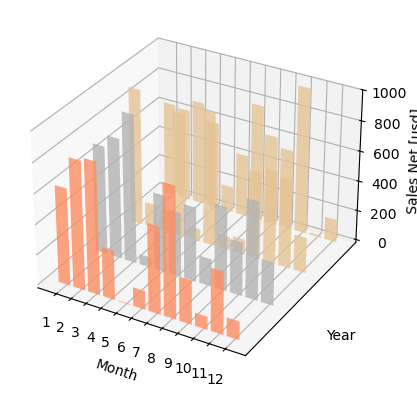

In [1]:
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from mpl_toolkits.mplot3d import Axes3D

mpl.rcParams['font.size'] = 10

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for z in [2011, 2012, 2013, 2014]:
    xs = range(1,13)
    ys = 1000 * np.random.rand(12)
    
    color = plt.cm.Set2(random.choice(range(plt.cm.Set2.N)))
    ax.bar(xs, ys, zs=z, zdir='y', color=color, alpha=0.8)

ax.xaxis.set_major_locator(mpl.ticker.FixedLocator(xs))
ax.yaxis.set_major_locator(mpl.ticker.FixedLocator(ys))

ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_zlabel('Sales Net [usd]')

plt.show()

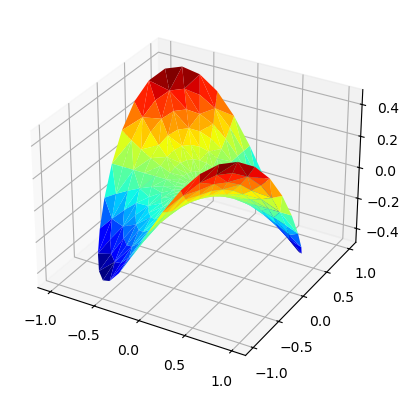

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

n_angles = 36
n_radii = 8

# An array of radii
# Does not include radius r=0, this is to eliminate duplicate points
radii = np.linspace(0.125, 1.0, n_radii)

# An array of angles
angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)

# Repeat all angles for each radius
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)

# Convert polar (radii, angles) coords to cartesian (x, y) coords
# (0, 0) is added here. There are no duplicate points in the (x,y) plane
x = np.append(0, (radii * np.cos(angles)).flatten())
y = np.append(0, (radii * np.sin(angles)).flatten())

# Pringle surface
z = np.sin(-x * y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') 
ax.plot_trisurf(x, y, z, cmap=cm.jet, linewidth=0.2)

plt.show()

## 5.3 创建3D直方图

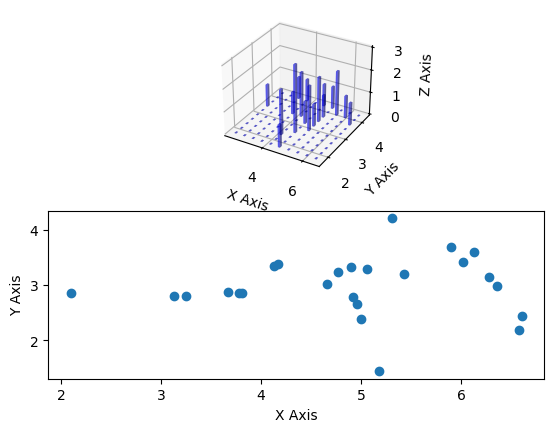

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from mpl_toolkits.mplot3d import Axes3D

mpl.rcParams['font.size'] = 10

samples = 25

x = np.random.normal(5, 1, samples)
y = np.random.normal(3, .5, samples)

fig = plt.figure()
ax = fig.add_subplot(211, projection='3d')

# compute two-dimensional histogram
hist, xedges, yedges = np.histogram2d(x, y, bins=10)

# compute location of the x,y bar positions
elements = (len(xedges) - 1) * (len(yedges) - 1)
xpos, ypos = np.meshgrid(xedges[:-1]+.25, yedges[:-1]+.25)

xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros(elements)

# make every bar the same width in base
dx = .1 * np.ones_like(zpos)
dy = dx.copy()

# this defines the height of the bar
dz = hist.flatten()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='b', alpha=0.4)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# plot the same x,y correlation in scatter plot
# for comparison
ax2 = fig.add_subplot(212)
ax2.scatter(x, y)
ax2.set_xlabel('X Axis')
ax2.set_ylabel('Y Axis')

plt.show()

## 5.4 在matplotlib中创建动画

RuntimeError: Requested MovieWriter (ffmpeg) not available

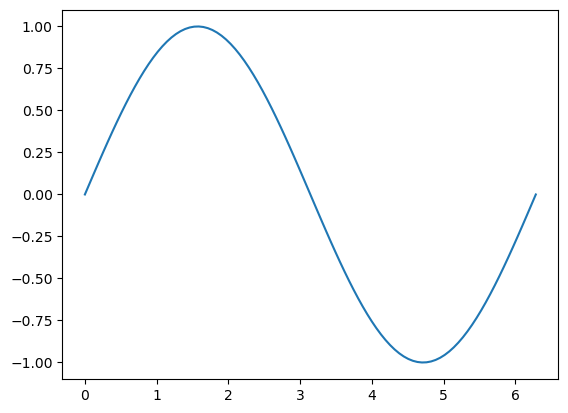

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # 用于在 Notebook 中嵌入动画

# 设置图形
fig, ax = plt.subplots()
x = np.linspace(0, 2*np.pi, 100)
line, = ax.plot(x, np.sin(x))  # 初始曲线

# 更新函数（每一帧调用）
def update(frame):
    line.set_ydata(np.sin(x + frame/10))  # 移动正弦波
    return line,

# 创建动画（帧数=100，间隔50ms）
anim = FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# 在 Notebook 中显示
HTML(anim.to_html5_video())  # 或 anim.to_jshtml()

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation

fig = plt.figure()
ax = plt.axes(xlim=(0, 2), ylim=(-2, 2))
line, = ax.plot([], [], lw=2)

def init():
    """Clears current frame."""
    line.set_data([], [])
    return line,
    
def animate(i):
    """Draw figure.
    @param i: Frame counter
    @type i: int
    """
x = np.linspace(0, 2, 1000)
y = np.sin(2 * np.pi * (x - 0.01 * i)) * np.cos(22 * np.pi *
(x –
0.01 * i))
line.set_data(x, y)
return line,
# This call puts the work in motion
# connecting init and animate functions and figure we want to draw
animator = animation.FuncAnimation(fig, animate, init_func=init,
frames=200, interval=20, blit=True)
# set blit to False if you're under OS X!
# This call creates the video file.
# Temporary, every frame is saved as PNG file
# and later processed by ffmpeg encoder into MPEG4 file
# we can pass various arguments to ffmpeg via extra_args
animator.save('basic_animation.mp4', fps=30,
extra_args=['-vcodec', 'libx264'],
writer='ffmpeg_file')
plt.show()